## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load Dataset

In [4]:
df = pd.read_csv('netflix_titles.csv')
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [5]:
df.shape

(8807, 12)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [10]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


## Data Cleaning 

In [11]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [14]:
# Handling Missing Values
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')

In [17]:
df.dropna(subset=['date_added'], inplace=True)

In [19]:
# Convert to datetime
df['date_added'] = df['date_added'].str.strip()
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

## Exploratory Data Analysis (EDA)

In [21]:
# Count of Movies vs TV Shows
df['type'].value_counts()

type
Movie      6131
TV Show    2666
Name: count, dtype: int64

In [22]:
# Most frequent release years
df['release_year'].value_counts().head()

release_year
2018    1146
2017    1032
2019    1030
2020     953
2016     901
Name: count, dtype: int64

## Visualizations

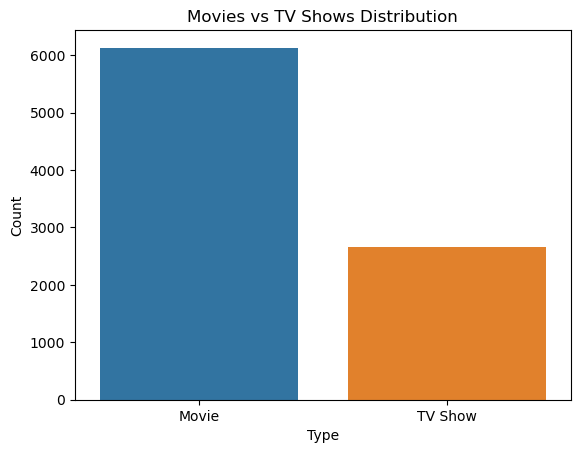

In [23]:
# Movies vs TV Shows
sns.countplot(x='type', data=df)
plt.title('Movies vs TV Shows Distribution')
plt.xlabel('Type')
plt.ylabel('Count')
plt.show()

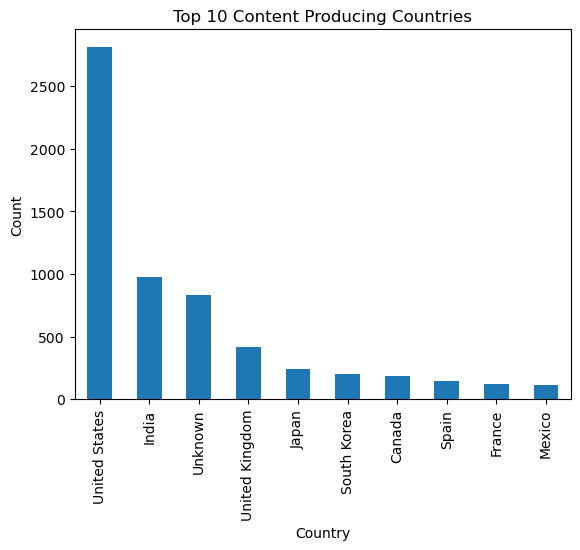

In [24]:
# Top 10 Countries
df['country'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Content Producing Countries')
plt.xlabel('Country')
plt.ylabel('Count')
plt.show()

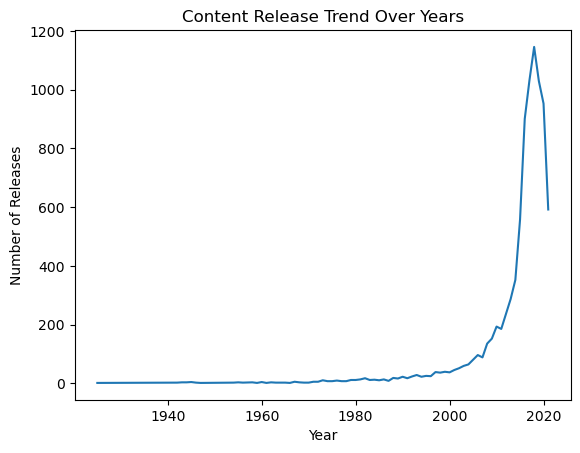

In [25]:
# Content Release Trend Over Years
df['release_year'].value_counts().sort_index().plot()
plt.title('Content Release Trend Over Years')
plt.xlabel('Year')
plt.ylabel('Number of Releases')
plt.show()

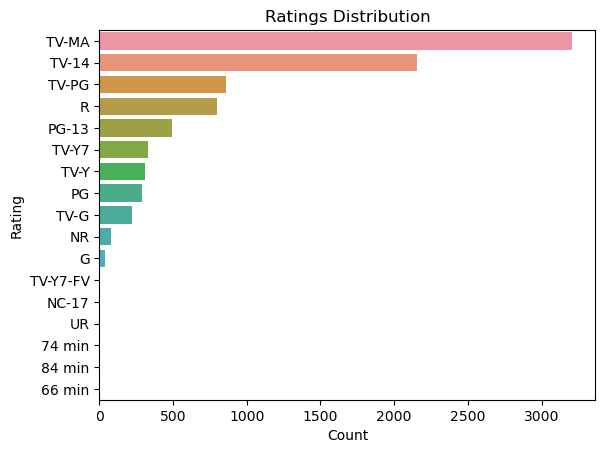

In [27]:
# Ratings Distribution
sns.countplot(y='rating', data=df, order=df['rating'].value_counts().index)
plt.title('Ratings Distribution')
plt.xlabel('Count')
plt.ylabel('Rating')
plt.show()

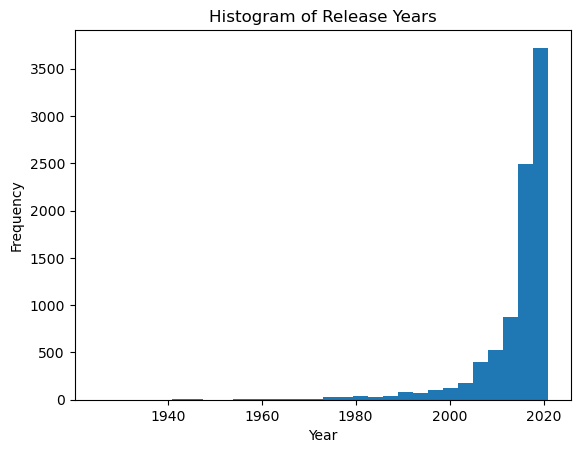

In [28]:
# Histogram of Release Year
plt.hist(df['release_year'], bins=30)
plt.title('Histogram of Release Years')
plt.xlabel('Year')
plt.ylabel('Frequency')
plt.show()

## Advanced Analysis

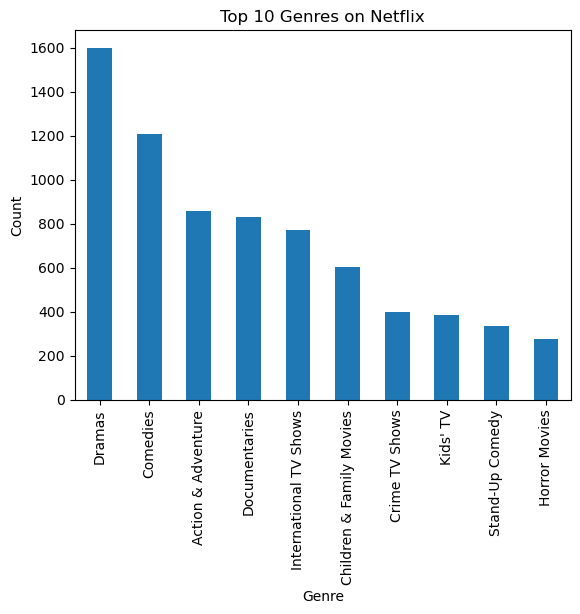

In [34]:
# Extraction of main genre (first listed genre)
df['main_genre'] = df['listed_in'].apply(lambda x: x.split(',')[0])

# Top Genres
top_genres = df['main_genre'].value_counts().head(10)

plt.figure()
top_genres.plot(kind='bar')
plt.title('Top 10 Genres on Netflix')
plt.xlabel('Genre')
plt.ylabel('Count')
plt.show()

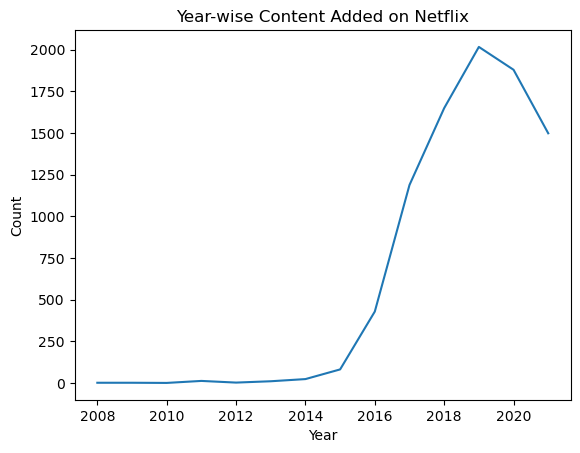

In [30]:
# Year-wise Content Added
df['year_added'] = df['date_added'].dt.year

df['year_added'].value_counts().sort_index().plot()
plt.title('Year-wise Content Added on Netflix')
plt.xlabel('Year')
plt.ylabel('Count')
plt.show()

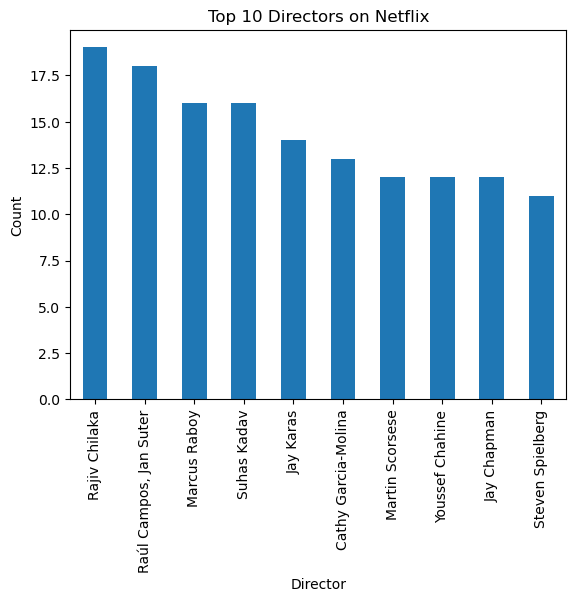

In [35]:
# Top 10 Directors 
directors = df[df['director'] != 'Unknown']
top_directors = directors['director'].value_counts().head(10)

# Top Directors
plt.figure()
top_directors.plot(kind='bar')
plt.title('Top 10 Directors on Netflix')
plt.xlabel('Director')
plt.ylabel('Count')
plt.show()

## Insights
####  1. Netflix has more movies than TV shows.
####  2. Content production increased significantly after 2015.
####  3. Majority of content is produced by the USA.
####  4. Drama and International content dominate Netflix catalog.
####  5. Content addition peaked after 2016.

## Conclusion

This analysis of the Netflix dataset provides meaningful insights into content trends, distribution, and platform strategy.

The study shows that Netflix offers a significantly higher number of movies compared to TV shows, indicating a stronger focus on movie-based content. Over the years, there has been a noticeable increase in content production, especially after 2015, which reflects Netflix’s rapid global expansion and investment in original content.

From a regional perspective, the majority of content is produced in the United States, followed by contributions from other countries, highlighting Netflix’s global reach. Genre analysis reveals that categories like Drama and International content dominate the platform, suggesting a preference for diverse and widely appealing storytelling.

Overall, the analysis demonstrates how Netflix strategically expands its content library to cater to a broad audience, balancing quantity, diversity, and accessibility. These insights highlight the importance of data analytics in understanding user preferences and guiding business decisions in the entertainment industry.